In [ ]:
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "cheerathaniketh",
    "key": "xxxxxxxxxxxxxxxxxxxxxxxxxx"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [22]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))


True Tesla T4


In [23]:
!kaggle datasets list -s "oil spill"

ref                                                              title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sudhanshu2198/oil-spill-detection                                Oil Spill Classification                                79347  2022-11-12 11:34:27.303000           4902         92  0.9411765        
imtkaggleteam/oil-spills                                         Oil Spills                                               2452  2023-08-02 11:33:10.027000           2701        104  1                
ashrafkhan94/oil-spill                                           Oil Spill                                               79140  2021-01-29 04:35:07.267000           2186         26  0.5882353        


In [24]:
import kagglehub
path = kagglehub.dataset_download("bakhtiyar2222/deep-sar-oil-spill-segmentation-refined")
print(path)

import os
for root, dirs, fnames in os.walk(path):
    print(root, dirs, fnames[:5])



100%|██████████| 1.09G/1.09G [00:15<00:00, 76.8MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1
/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1 ['masks', 'images'] []
/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks ['masks'] []
/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks/masks ['train', 'val'] []
/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks/masks/train [] ['sentinel_1435.png', 'palsar_264.png', 'palsar_176.png', 'sentinel_1321.png', 'sentinel_2980.png']
/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks/masks/val [] ['palsar_264.png', 'palsar_176.png', 'sentinel_618.png', 'palsar_468.png', 'sentinel_778.png']
/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/images ['ima

In [25]:
import numpy as np
from PIL import Image

mask_path = "/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks/masks/train/palsar_291.png"
img_path  = "/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/images/images/train/palsar_291.png"

mask = Image.open(mask_path)
img  = Image.open(img_path)

print("mask mode:", mask.mode, "size:", mask.size)
print("image mode:", img.mode, "size:", img.size)

mask_arr = np.array(mask)
print("mask array shape:", mask_arr.shape)
print("unique values in mask:", np.unique(mask_arr.reshape(-1, mask_arr.shape[-1]) if mask_arr.ndim==3 else mask_arr, axis=0)[:20])

mask mode: RGB size: (256, 256)
image mode: RGB size: (256, 256)
mask array shape: (256, 256, 3)
unique values in mask: [[ 0  0  0]
 [ 9  9  9]
 [10 10 10]
 [19 19 19]
 [20 20 20]
 [29 29 29]
 [30 30 30]
 [38 38 38]
 [39 39 39]
 [40 40 40]
 [41 41 41]
 [48 48 48]
 [49 49 49]
 [50 50 50]
 [51 51 51]
 [52 52 52]
 [58 58 58]
 [59 59 59]
 [60 60 60]
 [61 61 61]]


In [26]:
import numpy as np
from PIL import Image

mask = Image.open(mask_path)
mask_arr = np.array(mask)

# collapse to single channel since R=G=B
gray = mask_arr[:,:,0]

vals, counts = np.unique(gray, return_counts=True)
print("total unique values:", len(vals))
print("value : count")
for v, c in sorted(zip(vals, counts), key=lambda x: -x[1])[:15]:
    print(v, c)

total unique values: 115
value : count
0 59640
255 3077
154 175
101 174
9 166
207 159
48 150
246 134
19 125
236 103
29 102
39 97
226 90
216 87
122 66


In [27]:
import numpy as np
from PIL import Image
import glob
from collections import Counter

mask_files = glob.glob("/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks/masks/train/*.png")
print("total train masks:", len(mask_files))

global_counts = Counter()

for f in mask_files[:200]:
    arr = np.array(Image.open(f))
    if arr.ndim == 3:
        arr = arr[:, :, 0]   # collapse RGB (R=G=B) to single channel
    # if arr.ndim == 2, it's already single-channel, use as-is

    vals, counts = np.unique(arr, return_counts=True)
    for v, c in zip(vals, counts):
        global_counts[int(v)] += int(c)

top = global_counts.most_common(15)
print("top 15 values across 200 masks:")
for v, c in top:
    print(v, c)

total train masks: 6455
top 15 values across 200 masks:
0 9528508
255 3354234
9 13507
246 12537
19 8551
236 8257
29 8028
101 7874
154 7833
226 7801
216 6802
39 6785
207 5587
48 5451
60 5383


In [28]:
import numpy as np
from PIL import Image
import glob

f = mask_files[0]
arr = np.array(Image.open(f))
if arr.ndim == 3:
    arr = arr[:, :, 0]

# how much of the image is explained by *just* thresholding at 128?
binary_equivalent = np.isin(arr, [0]).sum() + np.isin(arr, [255]).sum()
print(binary_equivalent / arr.size)   # if this is >0.97+, it's binary + antialiasing, not 5-class

1.0


In [29]:
import glob
import numpy as np
from PIL import Image

mask_files = glob.glob("/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1/masks/masks/train/*.png")
print("files found:", len(mask_files))

binary_frac = []
midband_frac = []

for i, f in enumerate(mask_files[:200]):
    arr = np.array(Image.open(f))
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    total = arr.size
    binary_frac.append((np.isin(arr, [0, 255])).sum() / total)
    midband_frac.append(((arr > 40) & (arr < 215)).sum() / total)

print("processed:", len(binary_frac))  # <-- this is the number that matters

binary_frac = np.array(binary_frac)
midband_frac = np.array(midband_frac)

print("binary-only fraction: mean", binary_frac.mean(), "min", binary_frac.min())
print("mid-band (40-215) fraction: mean", midband_frac.mean(), "max", midband_frac.max())
print("masks with >1% mid-band pixels:", (midband_frac > 0.01).sum(), "/", len(midband_frac))

files found: 6455
processed: 200
binary-only fraction: mean 0.9828752136230469 min 0.795135498046875
mid-band (40-215) fraction: mean 0.009789810180664063 max 0.1250152587890625
masks with >1% mid-band pixels: 42 / 200


In [30]:
from scipy import ndimage

# grab the masks with the highest mid-band fraction
midband_frac = np.array(midband_frac)
top_idx = np.argsort(midband_frac)[::-1][:5]

for i in top_idx:
    f = mask_files[i]
    arr = np.array(Image.open(f))
    if arr.ndim == 3:
        arr = arr[:, :, 0]

    midband_mask = (arr > 40) & (arr < 215)
    eroded = ndimage.binary_erosion(midband_mask, iterations=2)

    before = midband_mask.sum()
    after = eroded.sum()
    survival = after / before if before > 0 else 0

    print(f"{f.split('/')[-1]}: midband_frac={midband_frac[i]:.4f}, "
          f"pixels_before={before}, pixels_after_erosion={after}, "
          f"survival={survival:.2%}")

palsar_565.png: midband_frac=0.1250, pixels_before=8193, pixels_after_erosion=175, survival=2.14%
palsar_446.png: midband_frac=0.1191, pixels_before=7807, pixels_after_erosion=182, survival=2.33%
palsar_707.png: midband_frac=0.1061, pixels_before=6956, pixels_after_erosion=144, survival=2.07%
sentinel_316.png: midband_frac=0.0963, pixels_before=6308, pixels_after_erosion=274, survival=4.34%
palsar_468.png: midband_frac=0.0946, pixels_before=6201, pixels_after_erosion=90, survival=1.45%


In [31]:
def remap_to_binary(arr):
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    return (arr >= 128).astype(np.uint8)  # 0 = sea, 1 = spill

# sanity check on a few files
for f in mask_files[:5]:
    arr = np.array(Image.open(f))
    remapped = remap_to_binary(arr)
    print(f.split('/')[-1], "unique values after remap:", np.unique(remapped),
          "spill pixel fraction:", remapped.mean())

sentinel_1435.png unique values after remap: [0 1] spill pixel fraction: 0.377777099609375
palsar_264.png unique values after remap: [0 1] spill pixel fraction: 0.1522674560546875
palsar_176.png unique values after remap: [0 1] spill pixel fraction: 0.0522003173828125
sentinel_1321.png unique values after remap: [0 1] spill pixel fraction: 0.435546875
sentinel_2980.png unique values after remap: [0 1] spill pixel fraction: 0.1959686279296875


In [32]:
import re
from collections import defaultdict

fracs_by_source = defaultdict(list)

for f in mask_files[:200]:
    arr = np.array(Image.open(f))
    remapped = remap_to_binary(arr)
    source = "palsar" if "palsar" in f.split('/')[-1] else "sentinel"
    fracs_by_source[source].append(remapped.mean())

for source, fracs in fracs_by_source.items():
    fracs = np.array(fracs)
    print(f"{source}: n={len(fracs)}, mean={fracs.mean():.3f}, "
          f"median={np.median(fracs):.3f}, >0.5 count={ (fracs > 0.5).sum() }")

sentinel: n=116, mean=0.290, median=0.215, >0.5 count=23
palsar: n=84, mean=0.229, median=0.178, >0.5 count=6


DATASET TESTING DONE

In [33]:
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class SpillSegDataset(Dataset):
    def __init__(self, image_files, mask_files, transform=None):
        assert len(image_files) == len(mask_files)
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_files[idx]).convert("RGB"))
        mask_arr = np.array(Image.open(self.mask_files[idx]))
        mask = self.remap_to_binary(mask_arr)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        return image, mask.long()

    @staticmethod
    def remap_to_binary(arr):
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        return (arr >= 128).astype(np.uint8)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [34]:
import os
import glob

base = "/root/.cache/kagglehub/datasets/bakhtiyar2222/deep-sar-oil-spill-segmentation-refined/versions/1"

def get_paired_files(split):
    img_dir = f"{base}/images/images/{split}"
    mask_dir = f"{base}/masks/masks/{split}"

    img_files = {os.path.basename(f): f for f in glob.glob(f"{img_dir}/*.png")}
    mask_files = {os.path.basename(f): f for f in glob.glob(f"{mask_dir}/*.png")}

    common = sorted(set(img_files) & set(mask_files))
    missing_img = set(mask_files) - set(img_files)
    missing_mask = set(img_files) - set(mask_files)
    if missing_img or missing_mask:
        print(f"[{split}] WARNING: {len(missing_img)} masks with no image, "
              f"{len(missing_mask)} images with no mask — dropped from pairing")

    image_paths = [img_files[k] for k in common]
    mask_paths = [mask_files[k] for k in common]
    print(f"[{split}] paired: {len(image_paths)}")
    return image_paths, mask_paths

train_images, train_masks = get_paired_files("train")
val_images, val_masks = get_paired_files("val")

[train] paired: 6455
[val] paired: 1615


In [35]:
train_dataset = SpillSegDataset(train_images, train_masks, transform=train_transform)
val_dataset = SpillSegDataset(val_images, val_masks, transform=val_transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(len(train_dataset), len(val_dataset))

6455 1615


In [36]:
!pip install -q segmentation_models_pytorch

import segmentation_models_pytorch as smp
import torch.nn as nn

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,          # binary → single-channel logit output
).to("cuda")

loss_fn = smp.losses.DiceLoss(mode="binary")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
import time

device = "cuda"
num_epochs = 15
best_val_dice = 0.0
checkpoint_path = "best_unet_spill.pth"

print(f"Device: {device}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
print(f"Batches per epoch: train={len(train_loader)}, val={len(val_loader)}")
print(f"Starting training for {num_epochs} epochs...\n")

def dice_iou_score(preds, targets, eps=1e-7):
    preds = (torch.sigmoid(preds) > 0.5).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)

    pred_area = preds.sum(dim=(1, 2, 3))
    target_area = targets.sum(dim=(1, 2, 3))
    iou_union = pred_area + target_area - intersection
    iou = (intersection + eps) / (iou_union + eps)

    return dice.mean().item(), iou.mean().item()


training_start = time.time()

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()
    print(f"\n{'='*50}")
    print(f"EPOCH {epoch}/{num_epochs}")
    print(f"{'='*50}")

    # ---- train ----
    model.train()
    train_loss = 0.0
    running_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch} [train]")
    for batch_idx, (images, masks) in enumerate(train_bar):
        images = images.to(device, non_blocking=True)
        masks = masks.unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        running_loss = loss.item()
        train_bar.set_postfix(loss=f"{running_loss:.4f}")

    train_loss /= len(train_dataset)
    print(f"Training pass done. Avg train_loss = {train_loss:.4f}")

    # ---- validate ----
    print("Running validation...")
    model.eval()
    val_loss = 0.0
    val_dice_total = 0.0
    val_iou_total = 0.0
    n_batches = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch} [val]")
        for images, masks in val_bar:
            images = images.to(device, non_blocking=True)
            masks = masks.unsqueeze(1).to(device, non_blocking=True)

            logits = model(images)
            loss = loss_fn(logits, masks)
            val_loss += loss.item() * images.size(0)

            dice, iou = dice_iou_score(logits, masks)
            val_dice_total += dice
            val_iou_total += iou
            n_batches += 1
            val_bar.set_postfix(dice=f"{dice:.4f}", iou=f"{iou:.4f}")

    val_loss /= len(val_dataset)
    val_dice = val_dice_total / n_batches
    val_iou = val_iou_total / n_batches

    epoch_time = time.time() - epoch_start
    print(f"\n--- Epoch {epoch} summary ---")
    print(f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_dice={val_dice:.4f} | val_iou={val_iou:.4f}")
    print(f"Epoch took {epoch_time:.1f}s ({epoch_time/60:.1f} min)")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✓ New best model saved (dice={val_dice:.4f}) → {checkpoint_path}")
    else:
        print(f"  (no improvement, best remains {best_val_dice:.4f})")

total_time = time.time() - training_start
print(f"\n{'='*50}")
print(f"TRAINING COMPLETE")
print(f"Total time: {total_time/60:.1f} min | Best val dice: {best_val_dice:.4f}")
print(f"{'='*50}")

Device: cuda
Train samples: 6455 | Val samples: 1615
Batches per epoch: train=404, val=101
Starting training for 15 epochs...


EPOCH 1/15


Epoch 1 [train]: 100%|██████████| 404/404 [01:10<00:00,  5.70it/s, loss=0.2893]


Training pass done. Avg train_loss = 0.3154
Running validation...


Epoch 1 [val]: 100%|██████████| 101/101 [00:08<00:00, 11.89it/s, dice=0.7577, iou=0.6228]



--- Epoch 1 summary ---
train_loss=0.3154 | val_loss=0.2123 | val_dice=0.7825 | val_iou=0.6776
Epoch took 79.4s (1.3 min)
✓ New best model saved (dice=0.7825) → best_unet_spill.pth

EPOCH 2/15


...


--- Epoch 14 summary ---
train_loss=0.1356 | val_loss=0.1236 | val_dice=0.8202 | val_iou=0.7245
Epoch took 85.3s (1.4 min)
  (no improvement, best remains 0.8265)

EPOCH 15/15


Epoch 15 [train]: 100%|██████████| 404/404 [01:14<00:00,  5.40it/s, loss=0.1377]


Training pass done. Avg train_loss = 0.1331
Running validation...


Epoch 15 [val]: 100%|██████████| 101/101 [00:08<00:00, 11.96it/s, dice=0.7943, iou=0.6715]


--- Epoch 15 summary ---
train_loss=0.1331 | val_loss=0.1253 | val_dice=0.8252 | val_iou=0.7282
Epoch took 83.3s (1.4 min)
  (no improvement, best remains 0.8265)

TRAINING COMPLETE
Total time: 20.8 min | Best val dice: 0.8265


In [ ]:
from google.colab import files
files.download('best_unet_spill.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
import torch
torch.manual_seed(14)

model.load_state_dict(torch.load('best_unet_spill.pth', map_location='cuda'))
model.eval()
print("Checkpoint loaded.")

Checkpoint loaded.


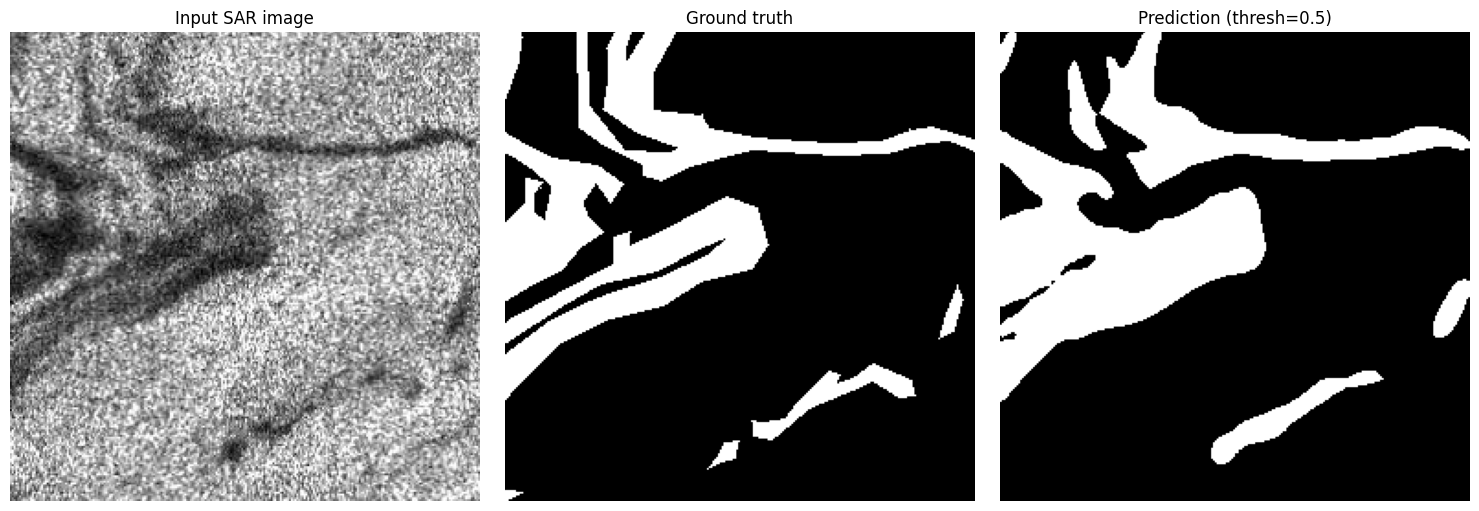

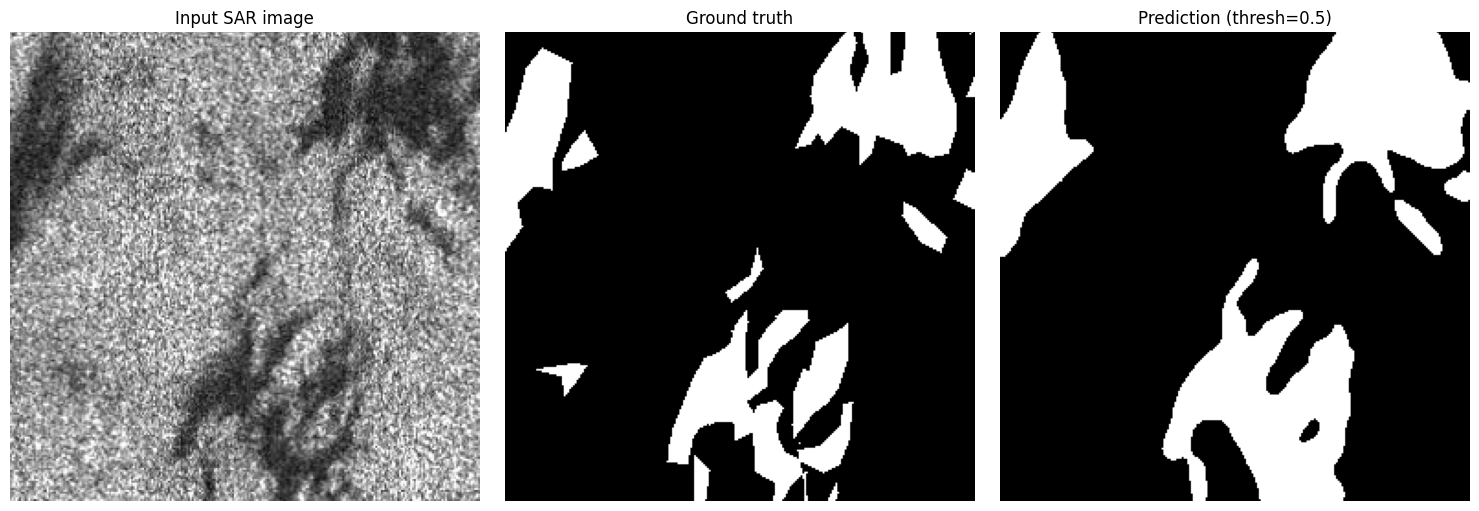

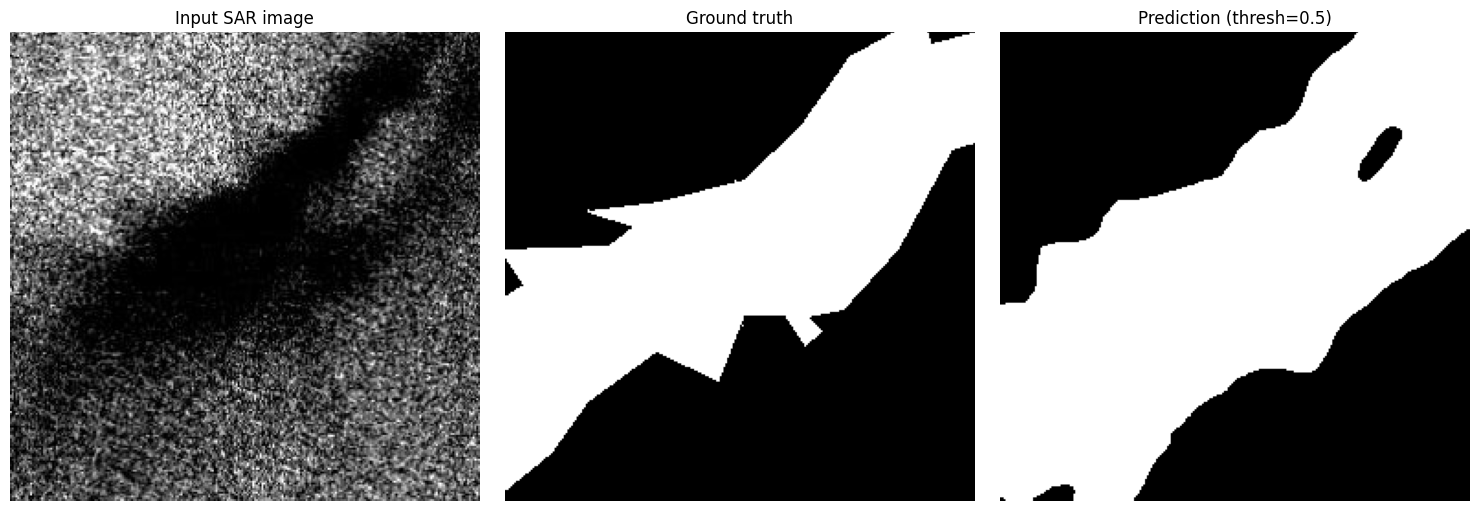

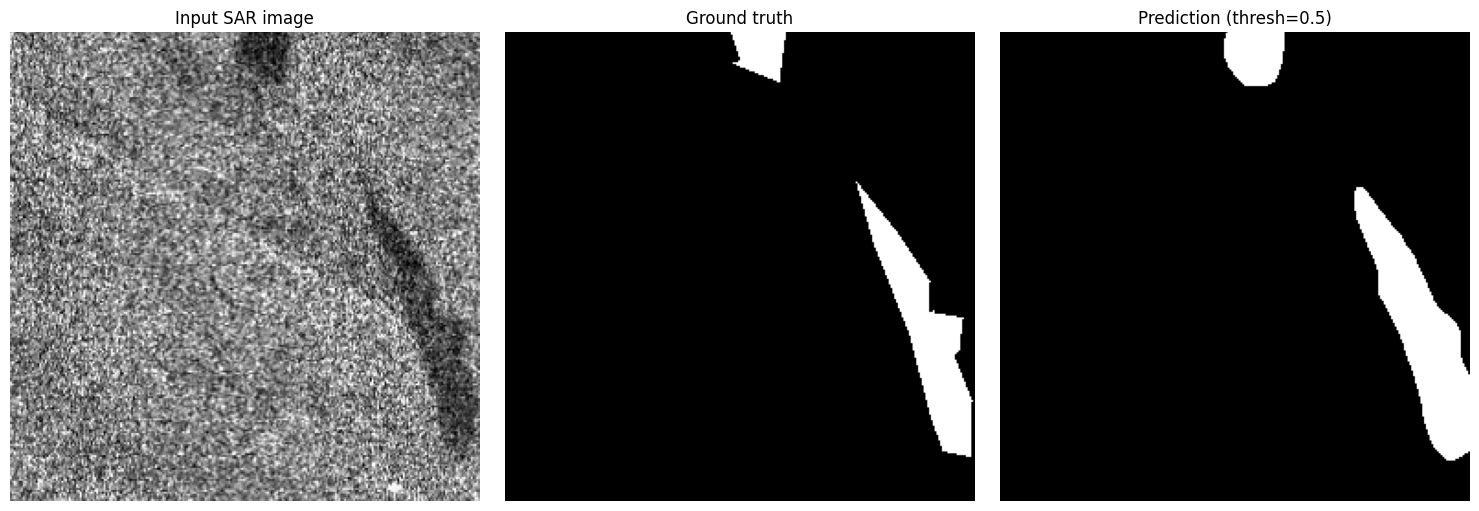

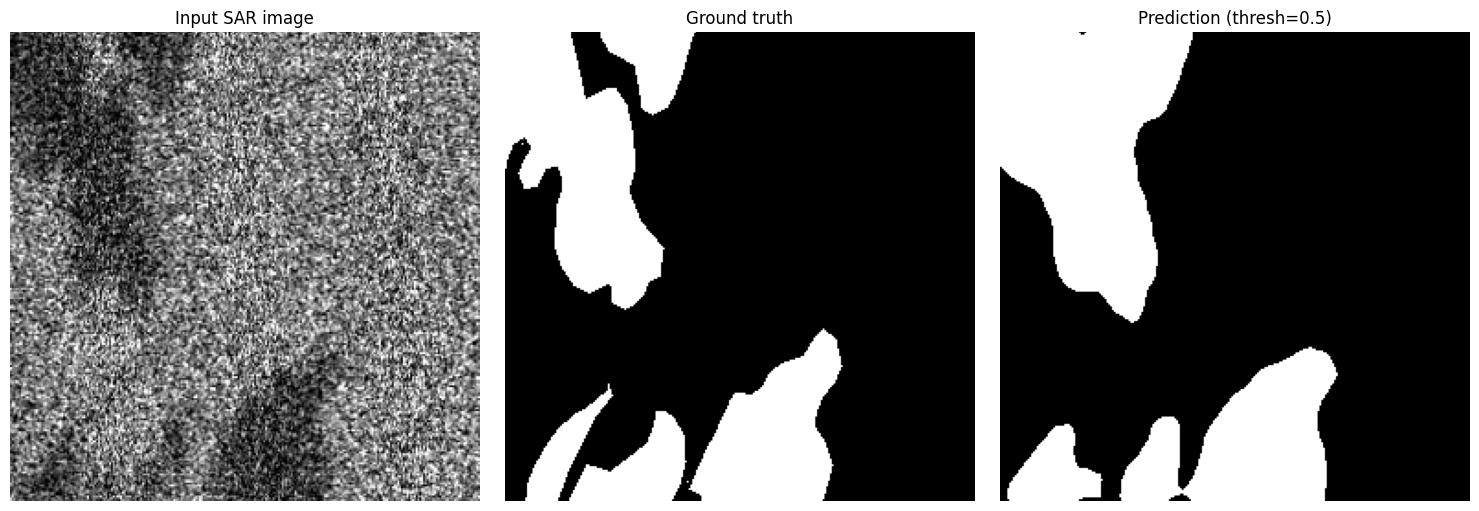

In [38]:
import matplotlib.pyplot as plt

def visualize_prediction(model, image_path, mask_path, transform, threshold=0.5, device="cuda"):
    image = np.array(Image.open(image_path).convert("RGB"))
    gt_mask = SpillSegDataset.remap_to_binary(np.array(Image.open(mask_path)))

    augmented = transform(image=image)
    input_tensor = augmented["image"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        prob = torch.sigmoid(model(input_tensor)).squeeze().cpu().numpy()
    pred_mask = (prob > threshold).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image); axes[0].set_title("Input SAR image")
    axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("Ground truth")
    axes[2].imshow(pred_mask, cmap="gray"); axes[2].set_title(f"Prediction (thresh={threshold})")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()

for i in range(5):
    visualize_prediction(model, val_images[i], val_masks[i], val_transform)

In [39]:
import cv2

def predict_mask(model, image_path, transform, threshold=0.5, device="cuda"):
    image = np.array(Image.open(image_path).convert("RGB"))
    augmented = transform(image=image)
    input_tensor = augmented["image"].unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()

    binary_mask = (prob > threshold).astype(np.uint8)
    return binary_mask, prob

def mask_to_spill_detection(binary_mask, prob, image_bounds, spill_id="spill_001", source_image="", detected_at=""):
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    h, w = binary_mask.shape
    min_lon, min_lat, max_lon, max_lat = image_bounds

    def px_to_lonlat(x, y):
        lon = min_lon + (x / w) * (max_lon - min_lon)
        lat = max_lat - (y / h) * (max_lat - min_lat)
        return [lon, lat]

    contours_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    main = contours_sorted[0]
    coords = [px_to_lonlat(pt[0][0], pt[0][1]) for pt in main]
    coords.append(coords[0])

    area_px = cv2.contourArea(main)
    perimeter_px = cv2.arcLength(main, True)

    if len(main) >= 5:
        (cx, cy), (d1, d2), angle = cv2.fitEllipse(main)
        major, minor = max(d1, d2), min(d1, d2)          # <-- fixed
        elongation = major / minor if minor > 0 else 1.0  # <-- fixed
    else:
        elongation = 1.0

    lon_km = (max_lon - min_lon) * 111.0
    lat_km = (max_lat - min_lat) * 111.0
    px_area_km2 = area_px * (lon_km / w) * (lat_km / h)
    px_perim_km = perimeter_px * ((lon_km/w + lat_km/h) / 2)

    return {
        "spill_id": spill_id,
        "source_image": source_image,
        "detected_at": detected_at,
        "polygon": {"type": "Polygon", "coordinates": [coords]},
        "bbox": [min_lon, min_lat, max_lon, max_lat],
        "area_km2": round(float(px_area_km2), 2),
        "perimeter_km": round(float(px_perim_km), 2),
        "elongation": round(float(elongation), 2),
        "fragment_count": len(contours),
        "confidence": float(prob[binary_mask == 1].mean()) if binary_mask.sum() > 0 else 0.0
    }

In [44]:
import json

# placeholder bounds — replace with real georeference once you know how AIS/drift will supply it
test_bounds = (72.70, 19.05, 72.76, 19.10)

test_idx = 0
binary_mask, prob = predict_mask(model, val_images[test_idx], val_transform)
result = mask_to_spill_detection(
    binary_mask, prob, test_bounds,
    spill_id="spill_test_001",
    source_image=val_images[test_idx].split('/')[-1],
    detected_at="2026-09-03T00:00:00Z"
)
print(json.dumps(result, indent=2))

{
  "spill_id": "spill_test_001",
  "source_image": "palsar_0.png",
  "detected_at": "2026-09-03T00:00:00Z",
  "polygon": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          72.7,
          19.089453125000002
        ],
        [
          72.7,
          19.0861328125
        ],
        [
          72.70023437500001,
          19.0861328125
        ],
        [
          72.700703125,
          19.085742187500003
        ],
        [
          72.70093750000001,
          19.085742187500003
        ],
        [
          72.70281250000001,
          19.0841796875
        ],
        [
          72.70281250000001,
          19.083984375
        ],
        [
          72.70375,
          19.083203125
        ],
        [
          72.703984375,
          19.083203125
        ],
        [
          72.704453125,
          19.082812500000003
        ],
        [
          72.7046875,
          19.082812500000003
        ],
        [
          72.705390625,
          1

In [41]:
import os
print(os.path.exists("best_unet_spill.pth"))

True


In [42]:
from google.colab import files
uploaded = files.upload()  # pick your .pth file from your computer

In [43]:
device = 'cuda'
model = smp.Unet(encoder_name="resnet18", encoder_weights="imagenet", classes=1, activation=None)
model.load_state_dict(torch.load("best_unet_spill.pth"))
model = model.to(device)
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track